# BanglaBERT Tense Classification — Replicating Sumon et al. (2026) Methodology

This notebook replicates the exact methodology used for BanglaBERT in **"A Novel Transformer-Based Framework for Bangla Tense Classification"** (Sumon et al., 2026 IEEE QPAIN), so results are directly comparable to their reported numbers.

**What's different from our other notebook (`BanglaBERT_Tense_Classification.ipynb`, trained on BengaliTenseCorpus):**
- **Dataset**: BanglaTense (17,819 sentences) instead of BengaliTenseCorpus (13,500)
- **Learning rate**: 3e-5 instead of 2e-5 (the paper's optimal value for BanglaBERT, found via grid search)
- **Epochs**: 16 instead of 5 (the paper's optimal value for BanglaBERT)
- **Max sequence length**: 512 instead of 128
- **Evaluation**: adds AUC-ROC (macro, one-vs-rest) alongside accuracy/precision/recall/F1

Everything else (stratified 80:10:10 split, AdamW optimizer, cross-entropy loss, dropout=0.1 classification head) already matched between our setup and the paper's.

In [ ]:
# GPU needed: NO (just mounting Drive)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 1: Load the BanglaTense dataset (17,819 sentences)

In [ ]:
# GPU needed: NO
import pandas as pd

folder = '/content/drive/MyDrive/Thesis_BanglaBERT'
file_path = f'{folder}/Cleaned-BanglaTense-WithEnglishTranslation.xlsx'

df = pd.read_excel(file_path)

print(f"Total Rows: {df.shape[0]}")
print(f"Columns: {df.columns.tolist()}")
print(df['Tense'].value_counts())
df.head()

Total Rows: 17819
Columns: ['Bangla Sentence', 'English Translation', 'Tense']
Tense
Present    6101
Future     6089
Past       5629
Name: count, dtype: int64


,Bangla Sentence,English Translation,Tense
0,তুমি আগামী মাসে পাঠ্যদান করবে,You will be teaching next month,Future
1,দারিদ্র্য একটি অসম্মানজনক বিষয় এবং এটি খুবই অ...,Poverty is a shameful thing and it is very inc...,Present
2,ছোট একটি অভিমান হয়ত একদিন বড় কোনো দূরত্বের স...,A small grudge may one day create a big distance,Present
3,স্মৃতির ভাইয়ের সাথে আমি যেন বস্তুত জড়িয়ে আছি,It's like I'm actually connected with Smriti's...,Present
4,আজকে আকাশের দিকে তাকিয়ে মনে হবে পৃথিবীটা কী অ...,"Looking at the sky today, you will think how w...",Future


## Step 2: Install libraries

In [ ]:
# GPU needed: NO
!pip install -q transformers datasets accelerate scikit-learn
!pip install -q git+https://github.com/csebuetnlp/normalizer
print("Libraries installed")

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.0/185.0 kB 10.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 7.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Libraries installed


## Step 3: Confirm GPU is connected

In [ ]:
# GPU needed: YES (this cell just checks it's available)
import torch

if torch.cuda.is_available():
    print(f"GPU connected: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU detected. Go to Runtime -> Change runtime type -> select a GPU.")

GPU connected: Tesla T4


## Step 4: Normalize text and encode labels

Same label convention used throughout this project: Present=0, Past=1, Future=2. (The paper uses a different internal numbering — Past=0, Present=1, Future=2 — but that's just an arbitrary index; it doesn't change accuracy/F1 results, so we keep our own convention for consistency with the rest of the thesis.)

In [ ]:
# GPU needed: NO
from normalizer import normalize

TEXT_COL = "Bangla Sentence"
LABEL_COL = "Tense"

df[TEXT_COL] = df[TEXT_COL].astype(str).apply(normalize)

tense_to_id = {"Present": 0, "Past": 1, "Future": 2}
id_to_tense = {number: tense_name for tense_name, number in tense_to_id.items()}
class_names = [id_to_tense[i] for i in range(len(id_to_tense))]

df["label_id"] = df[LABEL_COL].map(tense_to_id)

print("Label mapping:")
for tense_name, number in tense_to_id.items():
    print(f"  {tense_name} -> {number}")

df[[TEXT_COL, LABEL_COL, "label_id"]].head()

Label mapping:
  Present -> 0
  Past -> 1
  Future -> 2


,Bangla Sentence,Tense,label_id
0,তুমি আগামী মাসে পাঠ্যদান করবে,Future,2
1,দারিদ্র্য একটি অসম্মানজনক বিষয় এবং এটি খুবই অ...,Present,0
2,ছোট একটি অভিমান হয়ত একদিন বড় কোনো দূরত্বের স...,Present,0
3,স্মৃতির ভাইয়ের সাথে আমি যেন বস্তুত জড়িয়ে আছি,Present,0
4,আজকে আকাশের দিকে তাকিয়ে মনে হবে পৃথিবীটা কী অ...,Future,2


## Step 5: Stratified 80:10:10 split (matches the paper)

In [ ]:
# GPU needed: NO
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df, test_size=0.20, stratify=df["label_id"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label_id"], random_state=42
)

print(f"Train rows:      {len(train_df)}")
print(f"Validation rows: {len(val_df)}")
print(f"Test rows:       {len(test_df)}")

Train rows:      14255
Validation rows: 1782
Test rows:       1782


## Step 6: Load BanglaBERT tokenizer and model

`classifier_dropout=0.1` is set explicitly to match the paper's stated classification head (dropout p=0.1 -> linear -> softmax).

In [ ]:
# GPU needed: YES (loads model onto GPU)
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "csebuetnlp/banglabert"
NUM_LABELS = df["label_id"].nunique()

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS, classifier_dropout=0.1
)

print(f"Loaded {MODEL_NAME} with a classification head for {NUM_LABELS} classes")

config.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/528k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  443MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded csebuetnlp/banglabert with a classification head for 3 classes


## Step 7: Tokenize with max_length=512 (matches the paper; our other notebook used 128)

In [ ]:
# GPU needed: NO (tokenization is CPU work)
from datasets import Dataset

MAX_LENGTH = 512  # ceiling/cap (matches the paper) — most sentences are much shorter than this

def to_hf_dataset(pandas_df):
    small = pandas_df[[TEXT_COL, "label_id"]].rename(columns={TEXT_COL: "text", "label_id": "label"})
    return Dataset.from_pandas(small, preserve_index=False)

train_ds = to_hf_dataset(train_df)
val_ds = to_hf_dataset(val_df)
test_ds = to_hf_dataset(test_df)

# No fixed padding here — truncate only if a sentence exceeds MAX_LENGTH.
# Actual per-batch padding is handled dynamically by DataCollatorWithPadding
# in Step 8, which is much faster since real sentences are far shorter than 512.
def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

train_ds = train_ds.map(tokenize_fn, batched=True)
val_ds = val_ds.map(tokenize_fn, batched=True)
test_ds = test_ds.map(tokenize_fn, batched=True)

# Sanity check: see the actual token-length distribution (should be well under 512)
lengths = [len(x) for x in train_ds["input_ids"]]
import numpy as np
print(f"Token length — mean: {np.mean(lengths):.1f}, max: {max(lengths)}, 95th percentile: {np.percentile(lengths, 95):.0f}")

keep_cols = ["input_ids", "attention_mask", "label"]
train_ds.set_format(type="torch", columns=keep_cols)
val_ds.set_format(type="torch", columns=keep_cols)
test_ds.set_format(type="torch", columns=keep_cols)

print("Tokenization complete")
print(train_ds)


Map:   0%|          | 0/14255 [00:00<?, ? examples/s]

Map:   0%|          | 0/1782 [00:00<?, ? examples/s]

Map:   0%|          | 0/1782 [00:00<?, ? examples/s]

Token length — mean: 8.7, max: 55, 95th percentile: 18
Tokenization complete
Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 14255
})


## Step 8: Metrics (accuracy, macro P/R/F1, and AUC-ROC) + training config matching the paper's optimal BanglaBERT hyperparameters (Table V: lr=3e-5, batch_size=16, epochs=16)

In [ ]:
# GPU needed: NO (just defines things; training happens next cell)
import numpy as np
from scipy.special import softmax
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback, DataCollatorWithPadding

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    probs = softmax(logits, axis=-1)

    metrics = {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "precision_macro": precision_score(labels, preds, average="macro"),
        "recall_macro": recall_score(labels, preds, average="macro"),
    }
    try:
        metrics["auc_macro"] = roc_auc_score(labels, probs, multi_class="ovr", average="macro")
    except ValueError:
        metrics["auc_macro"] = float("nan")  # happens if a batch is missing a class
    return metrics

training_args = TrainingArguments(
    output_dir="/content/banglabert_paper_replication",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,          # paper's optimal for BanglaBERT (was 2e-5 in our other notebook)
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=16,         # paper's optimal for BanglaBERT (was 5 in our other notebook)
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_steps=50,
    report_to="none",
)

# The paper explicitly states early stopping (based on validation performance)
# was used to prevent overfitting. The paper doesn't give an exact patience
# value, so we use 3 epochs without improvement as a common, defensible default.
EARLY_STOPPING_PATIENCE = 3

# Dynamically pads each batch to the length of its longest sequence, instead
# of always padding to MAX_LENGTH=512 — much faster since real sentences are short.
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
)

print(f"Trainer is configured and ready (paper-matched hyperparameters, early stopping patience={EARLY_STOPPING_PATIENCE}, dynamic padding)")


Trainer is configured and ready (paper-matched hyperparameters, early stopping patience=3, dynamic padding)


## Step 9: Train

16 epochs on 14,255 rows will take noticeably longer than the 5-epoch run in the other notebook — expect roughly 45-90 minutes on a T4 GPU, depending on what Colab assigns.

In [ ]:
# GPU needed: YES (this is the actual training step)
import sys
sys.modules.pop("torchvision", None)  # avoid the broken torchvision video backend crashing datasets' torch formatter

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro,Auc Macro
1,0.056494,0.019461,0.996633,0.996584,0.996584,0.996584,0.998653
2,0.054495,0.025738,0.994949,0.994900,0.994800,0.995035,0.999348
3,0.019458,0.036416,0.994949,0.994925,0.994834,0.995034,0.998732
4,0.025076,0.020693,0.996633,0.996608,0.996550,0.996674,0.999691
5,0.035962,0.023369,0.995511,0.995494,0.995616,0.995399,0.999883
6,0.029595,0.036028,0.994949,0.994922,0.994862,0.994989,0.998792
7,0.007791,0.032348,0.994949,0.994961,0.994950,0.994991,0.999917


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=6237, training_loss=0.030056263096612655, metrics={'train_runtime': 621.1085, 'train_samples_per_second': 367.214, 'train_steps_per_second': 22.953, 'total_flos': 1020080956556970.0, 'train_loss': 0.030056263096612655, 'epoch': 7.0})

## Step 10: Final evaluation on the held-out test set (with AUC-ROC, matching the paper's Table II/III/IV reporting)

--- Classification Report (Test Set) ---
              precision    recall  f1-score   support

     Present       0.99      0.99      0.99       610
        Past       0.99      0.99      0.99       563
      Future       0.99      1.00      1.00       609

    accuracy                           0.99      1782
   macro avg       0.99      0.99      0.99      1782
weighted avg       0.99      0.99      0.99      1782

AUC-ROC (macro, one-vs-rest): 0.9991


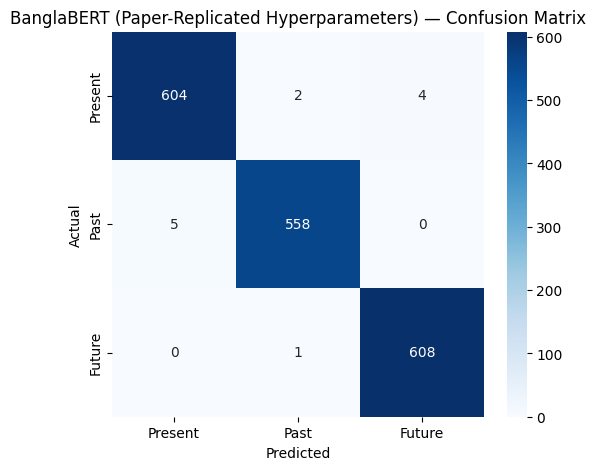

In [ ]:
# GPU needed: YES (running inference on the test set)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

predictions_output = trainer.predict(test_ds)
logits = predictions_output.predictions
y_pred = np.argmax(logits, axis=-1)
y_true = predictions_output.label_ids
probs = softmax(logits, axis=-1)

print("--- Classification Report (Test Set) ---")
print(classification_report(y_true, y_pred, target_names=class_names))

auc = roc_auc_score(y_true, probs, multi_class="ovr", average="macro")
print(f"AUC-ROC (macro, one-vs-rest): {auc:.4f}")

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=class_names, yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BanglaBERT (Paper-Replicated Hyperparameters) — Confusion Matrix")
plt.show()

## Step 11: Save the model to Drive

In [ ]:
# GPU needed: NO
SAVE_PATH = "/content/drive/MyDrive/Thesis_BanglaBERT/banglabert_paper_replication_model"

trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print(f"Model and tokenizer saved to: {SAVE_PATH}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to: /content/drive/MyDrive/Thesis_BanglaBERT/banglabert_paper_replication_model


In [ ]:
# GPU needed: YES (BanglaBERT inference)
import pandas as pd

# ------------------------------------------------------------
# Load the Chakma-Bengali CSV (no header in the file)
# ------------------------------------------------------------
chakma_folder = '/content/drive/MyDrive/Thesis_BanglaBERT'
chakma_path = f'{chakma_folder}/Copy of M_Tans_project_dataset - Sheet2.csv'

chakma_df = pd.read_csv(chakma_path, header=None, names=["Bengali", "Chakma"])
print(f"Total rows: {len(chakma_df)}")
print(chakma_df.head())

# ------------------------------------------------------------
# Predict Present/Past/Future for every row's Bengali text,
# using the model we just trained and saved (Step 12) — no retraining
# ------------------------------------------------------------
def predict_batch(sentences, batch_size=32):
    all_preds = []
    for i in range(0, len(sentences), batch_size):
        batch = sentences[i:i+batch_size]
        inputs = tokenizer(batch, truncation=True, padding=True, max_length=128, return_tensors="pt").to(model.device)
        with torch.no_grad():
            outputs = model(**inputs)
        preds = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
        all_preds.extend(preds)
    return all_preds

model.eval()
preds = predict_batch(chakma_df["Bengali"].astype(str).tolist())
chakma_df["Tense"] = [id_to_tense[p] for p in preds]

print("\nPredicted label distribution:")
print(chakma_df["Tense"].value_counts())

# ------------------------------------------------------------
# Save the labeled Chakma-Bengali dataset
# ------------------------------------------------------------
final_chakma_df = chakma_df[["Bengali", "Chakma", "Tense"]]
chakma_save_path = f"{chakma_folder}/ChakmaTenseCorpus_AutoLabeled.csv"
final_chakma_df.to_csv(chakma_save_path, index=False)

print(f"\n✓ Saved: {chakma_save_path}")
print(final_chakma_df.head(10))


Total rows: 3710
                                             Bengali  \
0                                    Fourth Division   
1  এগুলা কার জায়গা? কার ঘর? কার ছবি এইটি? কার কা...   
2                                      বেতের কুন্ডলী   
3  তোমার কাকা কোথায় গেছে? কাকারা আমাদের এখানে বে...   
4                                       খিল খিল হাসি   

                                              Chakma  
0                                     First Division  
1  𑄃𑄨𑄠𑄚𑄳𑄦𑄨 𑄇 𑄎𑄉? 𑄇 𑄊𑄧𑄢𑄴? 𑄇 𑄥𑄧𑄝𑄨 𑄃𑄨𑄞𑄬? 𑄇 𑄥𑄨𑄙𑄪 𑄎𑄧𑄖𑄴...  
2                                           𑄝𑄬𑄙𑄧 𑄇𑄇𑄴  
3  𑄖𑄧 𑄇𑄇𑄴𑄇 𑄇𑄪𑄙𑄪 𑄎𑄨𑄠𑄳𑄦𑄬? 𑄇𑄇𑄴𑄇𑄘𑄊𑄨 𑄃𑄟𑄳𑄦 𑄃𑄨𑄙𑄪 𑄝𑄬𑄢 𑄃𑄬𑄞𑄇𑄴𑅁  
4                                        𑄇𑄇𑄴 𑄇𑄇𑄴 𑄦𑄎𑄨  

Predicted label distribution:
Tense
Present    3067
Past        334
Future      309
Name: count, dtype: int64

✓ Saved: /content/drive/MyDrive/Thesis_BanglaBERT/ChakmaTenseCorpus_AutoLabeled.csv
                                             Bengali  \
0                                    Fourth Division   
1  এগুলা

## Step 13: Label the back-translated (synthetic) Chakma-Bengali dataset

This is the output of the back-translation step: raw/monolingual Chakma sentences translated to Bengali by the backward (Chakma→Bengali) model your thesis partner trained. It has a proper header (`chakma`, `bangla`), unlike the M_Tans file above.

Same idea as the M_Tans labeling above — reuse this notebook's trained BanglaBERT model (inference only, no retraining) to predict Present/Past/Future for the Bengali side, then carry that label over to the Chakma side.

In [ ]:
# GPU needed: YES (BanglaBERT inference)
import pandas as pd

# ------------------------------------------------------------
# Load the back-translated Chakma-Bengali CSV (this one has a
# proper header: "chakma", "bangla")
# ------------------------------------------------------------
mono_path = f'{chakma_folder}/chakma_mono_bangla_translations.csv'

mono_df = pd.read_csv(mono_path)
mono_df = mono_df.rename(columns={"chakma": "Chakma", "bangla": "Bengali"})
print(f"Total rows: {len(mono_df)}")
print(mono_df.head())

# ------------------------------------------------------------
# Predict Present/Past/Future for every row's Bengali text,
# reusing the same trained model and predict_batch() function
# defined above — no retraining
# ------------------------------------------------------------
model.eval()
mono_preds = predict_batch(mono_df["Bengali"].astype(str).tolist())
mono_df["Tense"] = [id_to_tense[p] for p in mono_preds]

print("\nPredicted label distribution:")
print(mono_df["Tense"].value_counts())

# ------------------------------------------------------------
# Save the labeled synthetic Chakma-Bengali dataset
# ------------------------------------------------------------
final_mono_df = mono_df[["Bengali", "Chakma", "Tense"]]
mono_save_path = f"{chakma_folder}/ChakmaTenseCorpus_BackTranslated_AutoLabeled.csv"
final_mono_df.to_csv(mono_save_path, index=False)

print(f"\n✓ Saved: {mono_save_path}")
print(final_mono_df.head(10))

## Step 12: Compare against the paper's reported numbers

Paper (Sumon et al. 2026), BanglaBERT on BanglaTense test set: **Accuracy 99.44%, Precision 99.43%, Recall 99.44%, F1-Score 99.43%, AUC 99.96%**.

Fill in your own results above once training finishes, and compare row by row.